#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.


### CHAPTER 20

**CH20B Fine tuning social media advertising**

using the ab-test-social-media dataset

version 1.0 2021-05-05

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from scipy.stats import ttest_ind
from statsmodels.stats.power import TTestIndPower

warnings.filterwarnings("ignore")


In [2]:
# Current script folder
current_path = os.getcwd()
dirname = current_path.split("da_case_studies")[0]

# location folders
data_in = dirname + "da_data_repo/ab-test-social-media/clean"
data_out = dirname + "da_case_studies/ch20-ab-test-social-media/"
output = dirname + "da_case_studies/ch20-ab-test-social-media/output/"

func = dirname + "da_case_studies/ch00-tech-prep/"
sys.path.append(func)


## Part I

sample size calculation

sample size calculation with planned rates

In [2]:
clickthrough = 0.01

conversion = 0.05

proportionA = clickthrough * conversion

proportionB = proportionA * 1.2

es = sms.proportion_effectsize(proportionA, proportionB)
# es = proportionB - proportionA
TTestIndPower().solve_power(es, power=0.8, alpha=0.05) * 2


1722229.7283214852

In [3]:
clickthrough = 0.0032

conversion = 0.0082

proportionA = clickthrough * conversion

proportionB = proportionA * 1.2

es = sms.proportion_effectsize(proportionA, proportionB)
# es = proportionB - proportionA
TTestIndPower().solve_power(es, power=0.8, alpha=0.05) * 2


32833930.604161125

## Part II

p-value of tests

In [4]:
# Install openpyxl if not already installed
%pip install openpyxl

summary_data = pd.read_excel("/workspaces/codespaces-jupyter/data/ab-test-summary.xlsx", engine="openpyxl")
# summary_data = pd.read_excel("https://osf.io/download/mhybr/").set_index("action_type")


Note: you may need to restart the kernel to use updated packages.


In [5]:
summary_data


,action_type,show,clicks,action
0,Action A,1000000,3323,32
1,Action B,1000000,3128,21


In [6]:
data = pd.DataFrame(0, columns=["type_b", "clicks", "action"], index=range(0, 2000000))
data.loc[0:999999, "type_b"] = 1
data

,type_b,clicks,action
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
1999995,0,0,0
1999996,0,0,0
1999997,0,0,0
1999998,0,0,0


In [7]:
# We already created the DataFrame in cell 10, no need to recreate it

# Reset clicks and action values
data.loc[:, ["clicks", "action"]] = 0

# Set clicks for Action A (type_b = 0)
action_a_clicks = summary_data.loc[summary_data["action_type"] == "Action A", "clicks"].values[0]
data.loc[0:action_a_clicks - 1, "clicks"] = 1

# Set clicks for Action B (type_b = 1)
action_b_clicks = summary_data.loc[summary_data["action_type"] == "Action B", "clicks"].values[0]
data.loc[1000000:1000000 + action_b_clicks - 1, "clicks"] = 1

# Set action for Action A (type_b = 0)
action_a_actions = summary_data.loc[summary_data["action_type"] == "Action A", "action"].values[0]
data.loc[0:action_a_actions - 1, "action"] = 1

# Set action for Action B (type_b = 1)
action_b_actions = summary_data.loc[summary_data["action_type"] == "Action B", "action"].values[0]
data.loc[1000000:1000000 + action_b_actions - 1, "action"] = 1


In [8]:
data.groupby(["type_b", "clicks"]).count()


action
type_b clicks        
0      0       996872
       1         3128
1      0       996677
       1         3323

In [9]:
data.groupby(["type_b", "action"]).count()

clicks
type_b action        
0      0       999979
       1           21
1      0       999968
       1           32

In [10]:
smf.ols("clicks ~ 1 + type_b", data).fit(cov_type="HC0").summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 clicks   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     5.914
Date:                Fri, 29 Aug 2025   Prob (F-statistic):             0.0150
Time:                        20:00:29   Log-Likelihood:             2.9020e+06
No. Observations:             2000000   AIC:                        -5.804e+06
Df Residuals:                 1999998   BIC:                        -5.804e+06
Df Model:                           1                                         
Covariance Type:                  HC0                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0031   5.58e-05     56.016      0.000       0.003       0.003
type_b         0.0002   8.02e-05      2.432      0.015    3.78e-05       0.000
==============================================================================
Omnibus:                  4075093.883   Durbin-Watson:                   0.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       7855996717.432
Skew:                          17.522   Prob(JB):                         0.00
Kurtosis:                     308.031   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC0)
"""

In [11]:
smf.ols("action ~ 1 + type_b", data).fit(cov_type="HC0").summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 action   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.283
Date:                Fri, 29 Aug 2025   Prob (F-statistic):              0.131
Time:                        20:00:31   Log-Likelihood:             7.7005e+06
No. Observations:             2000000   AIC:                        -1.540e+07
Df Residuals:                 1999998   BIC:                        -1.540e+07
Df Model:                           1                                         
Covariance Type:                  HC0                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     2.1e-05   4.58e-06      4.583      0.000     1.2e-05       3e-05
type_b        1.1e-05   7.28e-06      1.511      0.131   -3.27e-06    2.53e-05
===============================================================================
Omnibus:                  9693574.572   Durbin-Watson:                    0.057
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   118646783578266.656
Skew:                         194.249   Prob(JB):                          0.00
Kurtosis:                   37733.763   Cond. No.                          2.62
===============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC0)
"""

## I. Min Sample Size (Conservative when r = 0.5)
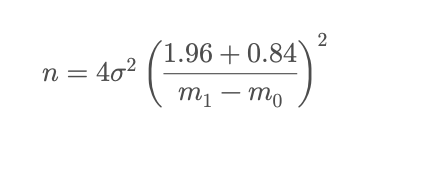

m0,m1 = means
#### 1.96 = 5% signicance level (Willing to accept a 5% chance of wrongly declaring that there’s an effect when there is no real effect. False Positive)
#### 0.84 = 80% power (20% of chance beta=0.2 of missing a true effect - False Negative)

### 1. Calc the proportions

In [12]:
summary_data

,action_type,show,clicks,action
0,Action A,1000000,3323,32
1,Action B,1000000,3128,21


In [24]:
rA = summary_data.loc[summary_data['action_type'] == 'Action A', 'action'].values[0] / summary_data.loc[summary_data['action_type'] == 'Action A', 'show'].values[0]
rB = summary_data.loc[summary_data['action_type'] == 'Action B', 'action'].values[0] / summary_data.loc[summary_data['action_type'] == 'Action B', 'show'].values[0]
r = (rA + rB) / 2

print(f"Rate for Action A: {rA}")
print(f"Rate for Action B: {rB}")
print(f"Average rate: {r}")


Rate for Action A: 3.2e-05
Rate for Action B: 2.1e-05
Average rate: 2.65e-05


### 2. Calc the Min Sample Size

In [33]:
Min_sample_size = 4 * r * (1-r) * ((1.96 + 0.84)/(rA-rB))**2
print(f"Need ~{Min_sample_size:.1f} million observations per group to detect a statistically significant difference at 5% significance level and 80% power between these action rates.")

Need ~6867917.2 million observations per group to detect a statistically significant difference at 5% significance level and 80% power between these action rates.


## II. Min Sample Size (Less conservative with exact power calculations)

In [34]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [35]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Action rates
p1 = 32 / 1_000_000  # Action A
p2 = 21 / 1_000_000  # Action B

# Effect size
effect_size = proportion_effectsize(p1, p2)

# Initialize power analysis
analysis = NormalIndPower()

# Calculate required sample size per group
sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,           # 80% power
    alpha=0.05,          # 5% significance
    ratio=1.0,           # Equal group sizes
    alternative='two-sided'
)

print(f"Required sample size per group: {sample_size:.0f}")

Required sample size per group: 3400411
